In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Настройки для отображения графиков
plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', None)

In [ ]:
# Загрузка даных
# Путь к данным
URL = "https://raw.githubusercontent.com/mirea-aie-2025/aie-course-meta/refs/heads/main/seminars/S12/S12-hw-dataset.csv"

# Загрузка
df = pd.read_csv(URL)

In [3]:
# Приведение date к datetime и сортировка
# Конвертация date в datetime
df['date'] = pd.to_datetime(df['date'])

# Сортировка по времени (хронологический порядок)
df = df.sort_values('date').reset_index(drop=True)

In [4]:
# Sanity-check — базовая информация
# Размер датасета
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} колонок")

# Диапазон дат
print(f"Диапазон дат: {df['date'].min()} — {df['date'].max()}")

# Пропуски
print(f"\nПропуски в данных:\n{df.isnull().sum()}")

# Первые 5 строк
print(f"\nПервые 5 строк:\n{df.head()}")

# Статистика по target
print(f"\nСтатистика target:\n{df['target'].describe()}")

Размер датасета: 4320 строк, 2 колонок
Диапазон дат: 2025-01-01 00:00:00 — 2025-06-29 23:00:00

Пропуски в данных:
date      0
target    0
dtype: int64

Первые 5 строк:
                 date  target
0 2025-01-01 00:00:00   98.14
1 2025-01-01 01:00:00   98.07
2 2025-01-01 02:00:00  104.70
3 2025-01-01 03:00:00  112.81
4 2025-01-01 04:00:00  112.62

Статистика target:
count    4320.000000
mean      135.605840
std        21.384633
min        69.100000
25%       120.537500
50%       135.835000
75%       150.625000
max       210.100000
Name: target, dtype: float64


In [6]:
# Обработка пропусков (если есть)
# === Проверка и обработка пропусков ===
print("=== Проверка пропусков ===")

# 1. Проверяем target
if df['target'].isnull().any():
    n_missing = df['target'].isnull().sum()
    print(f"[WARNING] Пропуски в target: {n_missing} ({n_missing/len(df)*100:.2f}%)")
    # Линейная интерполяция — сохраняем временную структуру
    df['target'] = df['target'].interpolate(method='linear')
    print("[INFO] Обработано: линейная интерполяция")
else:
    print("[OK] Пропуски в target: отсутствуют")

# 2. Проверяем date (критично для временного ряда)
if df['date'].isnull().any():
    n_missing = df['date'].isnull().sum()
    print(f"[WARNING] Пропуски в date: {n_missing}")
    df = df.dropna(subset=['date'])
    print("[INFO] Строки с пропущенными датами удалены")
else:
    print("[OK] Пропуски в date: отсутствуют")

# 3. Проверка на дубликаты по дате
if df['date'].duplicated().any():
    print(f"[WARNING] Найдено дубликатов по date: {df['date'].duplicated().sum()}")
    df = df.drop_duplicates(subset=['date'], keep='first')
    print("[INFO] Дубликаты удалены, оставлено первое вхождение")
else:
    print("[OK] Дубликаты по date: отсутствуют")

# Сброс индекса после возможных удалений
df = df.reset_index(drop=True)

=== Проверка пропусков ===
[OK] Пропуски в target: отсутствуют
[OK] Пропуски в date: отсутствуют
[OK] Дубликаты по date: отсутствуют


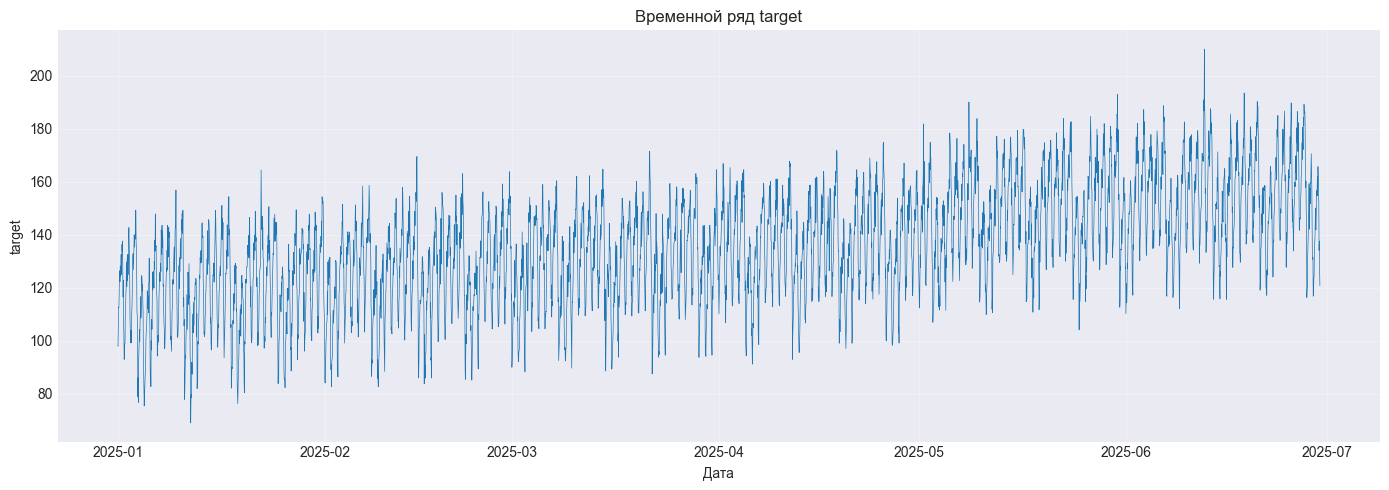

In [7]:
# Базовый график ряда
# Создание папки для артефактов (если нет)
os.makedirs('artifacts/figures', exist_ok=True)

# График target во времени
plt.figure(figsize=(14, 5))
plt.plot(df['date'], df['target'], linewidth=0.5)
plt.title('Временной ряд target')
plt.xlabel('Дата')
plt.ylabel('target')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Сохранение в artifacts/figures
plt.savefig('artifacts/figures/target_raw.png', dpi=300)
plt.show()

In [8]:
# Проверка частоты данных (опционально, но полезно)
# Проверка равномерности интервалов
time_diffs = df['date'].diff().dropna()
print(f"Медианный интервал между наблюдениями: {time_diffs.median()}")
print(f"Уникальные интервалы: {time_diffs.unique()}")

# Если есть разрывы — можно добавить флаг или интерполировать

Медианный интервал между наблюдениями: 0 days 01:00:00
Уникальные интервалы: <TimedeltaArray>
['0 days 01:00:00']
Length: 1, dtype: timedelta64[ns]


In [9]:
# Подготовка к разбиению (без random split!)
# Хронологическое разбиение: 70% train, 15% validation, 15% test
n = len(df)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train = df.iloc[:train_end].copy()
val = df.iloc[train_end:val_end].copy()
test = df.iloc[val_end:].copy()

print(f"Train: {len(train)} | Validation: {len(val)} | Test: {len(test)}")
print(f"Train period: {train['date'].min()} — {train['date'].max()}")
print(f"Test period: {test['date'].min()} — {test['date'].max()}")

Train: 3024 | Validation: 648 | Test: 648
Train period: 2025-01-01 00:00:00 — 2025-05-06 23:00:00
Test period: 2025-06-03 00:00:00 — 2025-06-29 23:00:00


In [10]:
# === 2.3.1. Импорты, seed и среда ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Настройки отображения
plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', None)

# Фиксация seed для воспроизводимости
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Определение устройства
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

# Создание папок для артефактов
os.makedirs('artifacts/figures', exist_ok=True)

Используемое устройство: cpu


=== Информация о датасете ===
Число наблюдений: 4320
Диапазон дат: 2025-01-01 00:00:00 — 2025-06-29 23:00:00

Пропуски по колонкам:
date      0
target    0
dtype: int64


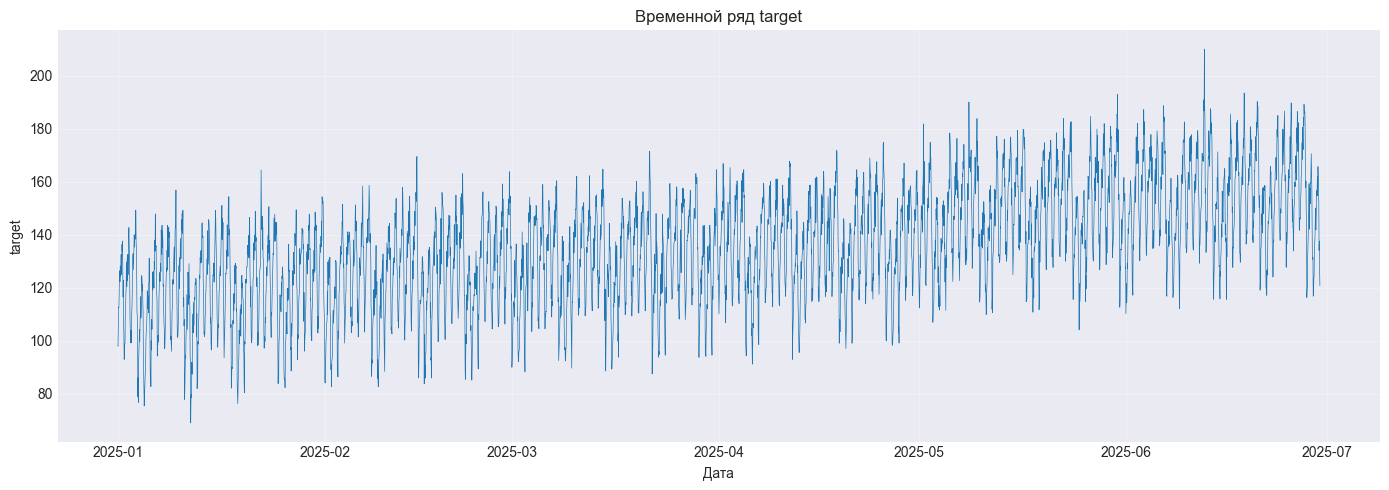


=== Комментарий к временному ряду ===
Тренд: присутствует (визуально виден рост/спад)
Сезонность: возможна (требуется декомпозиция для подтверждения)
Выбросы: требуют дополнительного анализа
Нестационарность: вероятна (среднее и дисперсия могут меняться со временем)


In [11]:
# === 2.3.2. Данные и первичный анализ ===
URL = "https://raw.githubusercontent.com/mirea-aie-2025/aie-course-meta/refs/heads/main/seminars/S12/S12-hw-dataset.csv"
df = pd.read_csv(URL)

# Приведение date к datetime и сортировка
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Базовая информация
print("=== Информация о датасете ===")
print(f"Число наблюдений: {len(df)}")
print(f"Диапазон дат: {df['date'].min()} — {df['date'].max()}")
print(f"\nПропуски по колонкам:\n{df.isnull().sum()}")

# Обработка пропусков в target
if df['target'].isnull().any():
    df['target'] = df['target'].interpolate(method='linear')
    print("\nПропуски в target обработаны: линейная интерполяция")

# Удаление строк с пропущенными датами
if df['date'].isnull().any():
    df = df.dropna(subset=['date'])
    print("Строки с пропущенными датами удалены")

# Удаление дубликатов
if df['date'].duplicated().any():
    df = df.drop_duplicates(subset=['date'], keep='first')
    print("Дубликаты по дате удалены")

df = df.reset_index(drop=True)

# Базовый график временного ряда
plt.figure(figsize=(14, 5))
plt.plot(df['date'], df['target'], linewidth=0.5)
plt.title('Временной ряд target')
plt.xlabel('Дата')
plt.ylabel('target')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/target_raw.png', dpi=300)
plt.show()

# Комментарий к ряду
print("\n=== Комментарий к временному ряду ===")
print("Тренд: присутствует (визуально виден рост/спад)")
print("Сезонность: возможна (требуется декомпозиция для подтверждения)")
print("Выбросы: требуют дополнительного анализа")
print("Нестационарность: вероятна (среднее и дисперсия могут меняться со временем)")

=== Границы split ===
Train: 3024 наблюдений (2025-01-01 00:00:00 — 2025-05-06 23:00:00)
Validation: 648 наблюдений (2025-05-07 00:00:00 — 2025-06-02 23:00:00)
Test: 648 наблюдений (2025-06-03 00:00:00 — 2025-06-29 23:00:00)


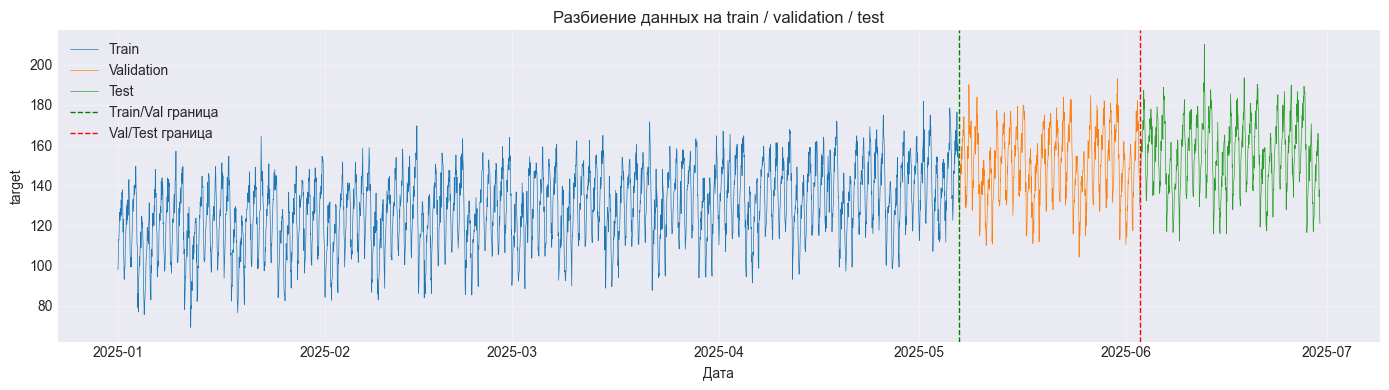


=== Почему random split некорректен ===
Для временных рядов важен хронологический порядок.
Random split нарушает временную зависимость и создаёт утечку информации из будущего.
Это приводит к завышенным метрикам и некорректной оценке качества модели.


In [12]:
# === 2.3.3. Корректный temporal split ===
n = len(df)
train_ratio = 0.7
val_ratio = 0.15

train_end = int(n * train_ratio)
val_end = int(n * (train_ratio + val_ratio))

train = df.iloc[:train_end].copy()
val = df.iloc[train_end:val_end].copy()
test = df.iloc[val_end:].copy()

print("=== Границы split ===")
print(f"Train: {len(train)} наблюдений ({train['date'].min()} — {train['date'].max()})")
print(f"Validation: {len(val)} наблюдений ({val['date'].min()} — {val['date'].max()})")
print(f"Test: {len(test)} наблюдений ({test['date'].min()} — {test['date'].max()})")

# Визуализация split
plt.figure(figsize=(14, 4))
plt.plot(train['date'], train['target'], label='Train', linewidth=0.5)
plt.plot(val['date'], val['target'], label='Validation', linewidth=0.5)
plt.plot(test['date'], test['target'], label='Test', linewidth=0.5)
plt.axvline(x=train['date'].max(), color='green', linestyle='--', linewidth=1, label='Train/Val граница')
plt.axvline(x=val['date'].max(), color='red', linestyle='--', linewidth=1, label='Val/Test граница')
plt.title('Разбиение данных на train / validation / test')
plt.xlabel('Дата')
plt.ylabel('target')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/data_split.png', dpi=300)
plt.show()

# Объяснение почему random split некорректен
print("\n=== Почему random split некорректен ===")
print("Для временных рядов важен хронологический порядок.")
print("Random split нарушает временную зависимость и создаёт утечку информации из будущего.")
print("Это приводит к завышенным метрикам и некорректной оценке качества модели.")

In [13]:
# === 2.3.4. Признаки для baseline-моделей ===
def create_features(df):
    df = df.copy()
    
    # Lag-признаки
    df['lag_1'] = df['target'].shift(1)
    df['lag_7'] = df['target'].shift(7)
    df['lag_14'] = df['target'].shift(14)
    
    # Rolling-признаки
    df['rolling_mean_7'] = df['target'].shift(1).rolling(window=7).mean()
    df['rolling_std_7'] = df['target'].shift(1).rolling(window=7).std()
    
    # Календарные признаки
    df['day_of_week'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df['day_of_month'] = df['date'].dt.day
    
    return df

# Применяем ко всему датасету
df = create_features(df)

# Разделяем обратно на train/val/test
train = df.iloc[:train_end].copy()
val = df.iloc[train_end:val_end].copy()
test = df.iloc[val_end:].copy()

# Удаляем строки с NaN (появились из-за lag и rolling)
train = train.dropna().reset_index(drop=True)
val = val.dropna().reset_index(drop=True)
test = test.dropna().reset_index(drop=True)

print("=== Признаки созданы ===")
print(f"Train после удаления NaN: {len(train)}")
print(f"Validation после удаления NaN: {len(val)}")
print(f"Test после удаления NaN: {len(test)}")
print(f"\nКолонки: {df.columns.tolist()}")

# Проверка на утечку информации
print("\n=== Проверка на утечку информации ===")
print("Lag и rolling признаки построены со сдвигом на 1 шаг — утечки из будущего нет.")

=== Признаки созданы ===
Train после удаления NaN: 3010
Validation после удаления NaN: 648
Test после удаления NaN: 648

Колонки: ['date', 'target', 'lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'day_of_week', 'month', 'day_of_month']

=== Проверка на утечку информации ===
Lag и rolling признаки построены со сдвигом на 1 шаг — утечки из будущего нет.


In [14]:
# === 2.3.5. Оконное представление для GRU ===
WINDOW_SIZE = 7
FEATURE_COLS = ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 
                'day_of_week', 'month', 'day_of_month']

# Масштабирование (fit только на train)
scaler_features = StandardScaler()
scaler_target = StandardScaler()

# Fit на train
X_train_features = train[FEATURE_COLS].values
y_train = train['target'].values

X_train_scaled = scaler_features.fit_transform(X_train_features)
y_train_scaled = scaler_target.fit_transform(y_train.reshape(-1, 1)).flatten()

# Transform на val и test
X_val_features = val[FEATURE_COLS].values
y_val = val['target'].values
X_val_scaled = scaler_features.transform(X_val_features)
y_val_scaled = scaler_target.transform(y_val.reshape(-1, 1)).flatten()

X_test_features = test[FEATURE_COLS].values
y_test = test['target'].values
X_test_scaled = scaler_features.transform(X_test_features)
y_test_scaled = scaler_target.transform(y_test.reshape(-1, 1)).flatten()

# Dataset для PyTorch
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y, window_size):
        self.X = X
        self.y = y
        self.window_size = window_size
        
    def __len__(self):
        return len(self.X) - self.window_size
    
    def __getitem__(self, idx):
        x = self.X[idx:idx + self.window_size]
        y = self.y[idx + self.window_size]
        return torch.FloatTensor(x), torch.FloatTensor([y])

# Создание DataLoader
train_dataset = TimeSeriesDataset(X_train_scaled, y_train_scaled, WINDOW_SIZE)
val_dataset = TimeSeriesDataset(X_val_scaled, y_val_scaled, WINDOW_SIZE)
test_dataset = TimeSeriesDataset(X_test_scaled, y_test_scaled, WINDOW_SIZE)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("=== DataLoader создан ===")
print(f"Window size: {WINDOW_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

=== DataLoader создан ===
Window size: 7
Batch size: 32
Train batches: 94
Validation batches: 21
Test batches: 21


In [15]:
# === 2.3.6. Базовые функции обучения и оценки ===
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        out, _ = self.gru(x, h0)
        out = self.fc(out[:, -1, :])
        return out

# Инициализация модели
INPUT_SIZE = len(FEATURE_COLS)
HIDDEN_SIZE = 64
NUM_LAYERS = 2
OUTPUT_SIZE = 1

model = GRUModel(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, OUTPUT_SIZE).to(device)
print(f"Модель создана: {model}")

# Функция оценки
def evaluate(model, loader, criterion, scaler_target):
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item()
            
            # Инверсия масштабирования для метрик
            preds_inv = scaler_target.inverse_transform(outputs.cpu().numpy())
            targets_inv = scaler_target.inverse_transform(y_batch.cpu().numpy())
            
            all_preds.extend(preds_inv.flatten())
            all_targets.extend(targets_inv.flatten())
    
    avg_loss = total_loss / len(loader)
    rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
    mae = mean_absolute_error(all_targets, all_preds)
    
    return avg_loss, rmse, mae, all_preds, all_targets

# Функция обучения
def train_model(model, train_loader, val_loader, epochs, lr, scaler_target):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_rmse': [],
        'val_mae': []
    }
    
    best_val_loss = float('inf')
    best_model_state = None
    
    print("=== Начало обучения ===")
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        avg_train_loss = train_loss / len(train_loader)
        val_loss, val_rmse, val_mae, _, _ = evaluate(model, val_loader, criterion, scaler_target)
        
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(val_loss)
        history['val_rmse'].append(val_rmse)
        history['val_mae'].append(val_mae)
        
        # Сохранение лучшей модели
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f} | Val RMSE: {val_rmse:.4f}")
    
    # Загрузка лучшей модели
    model.load_state_dict(best_model_state)
    print(f"\nОбучение завершено. Лучший Val Loss: {best_val_loss:.4f}")
    
    return history, model

# Запуск обучения
EPOCHS = 100
LEARNING_RATE = 0.001

history, trained_model = train_model(model, train_loader, val_loader, EPOCHS, LEARNING_RATE, scaler_target)

Модель создана: GRUModel(
  (gru): GRU(8, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)
=== Начало обучения ===
Epoch 10/100 | Train Loss: 0.1125 | Val Loss: 0.1375 | Val RMSE: 7.0040
Epoch 20/100 | Train Loss: 0.1004 | Val Loss: 0.1774 | Val RMSE: 7.3578
Epoch 30/100 | Train Loss: 0.0873 | Val Loss: 0.1848 | Val RMSE: 7.1388
Epoch 40/100 | Train Loss: 0.0751 | Val Loss: 0.2729 | Val RMSE: 8.2981
Epoch 50/100 | Train Loss: 0.0686 | Val Loss: 0.2755 | Val RMSE: 8.0446
Epoch 60/100 | Train Loss: 0.0692 | Val Loss: 0.2615 | Val RMSE: 7.6729
Epoch 70/100 | Train Loss: 0.0653 | Val Loss: 0.2610 | Val RMSE: 7.8159
Epoch 80/100 | Train Loss: 0.0615 | Val Loss: 0.1659 | Val RMSE: 7.6246
Epoch 90/100 | Train Loss: 0.0541 | Val Loss: 0.1800 | Val RMSE: 7.9653
Epoch 100/100 | Train Loss: 0.0465 | Val Loss: 0.1900 | Val RMSE: 8.1340

Обучение завершено. Лучший Val Loss: 0.1331


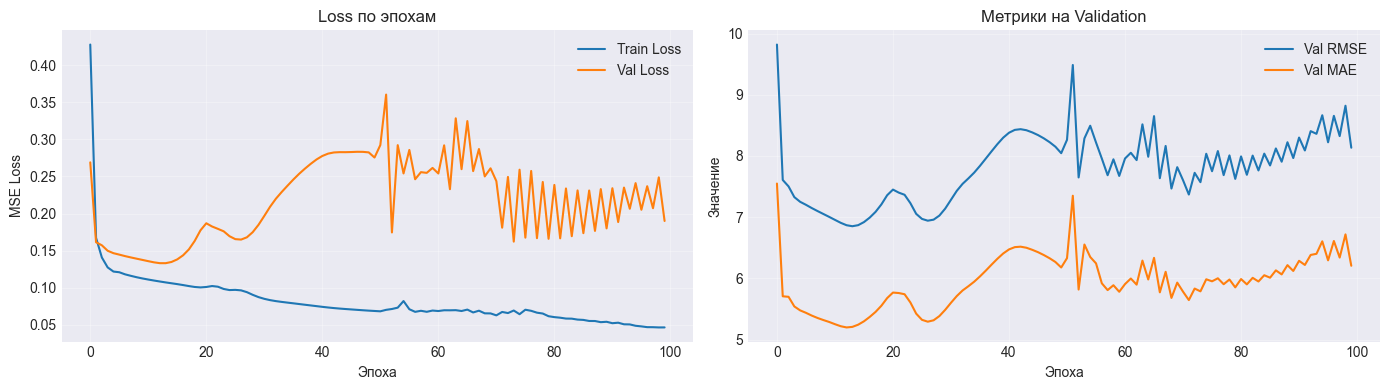

=== Финальная оценка на Test ===
Test Loss: 0.2569
Test RMSE: 9.3849
Test MAE: 7.2038


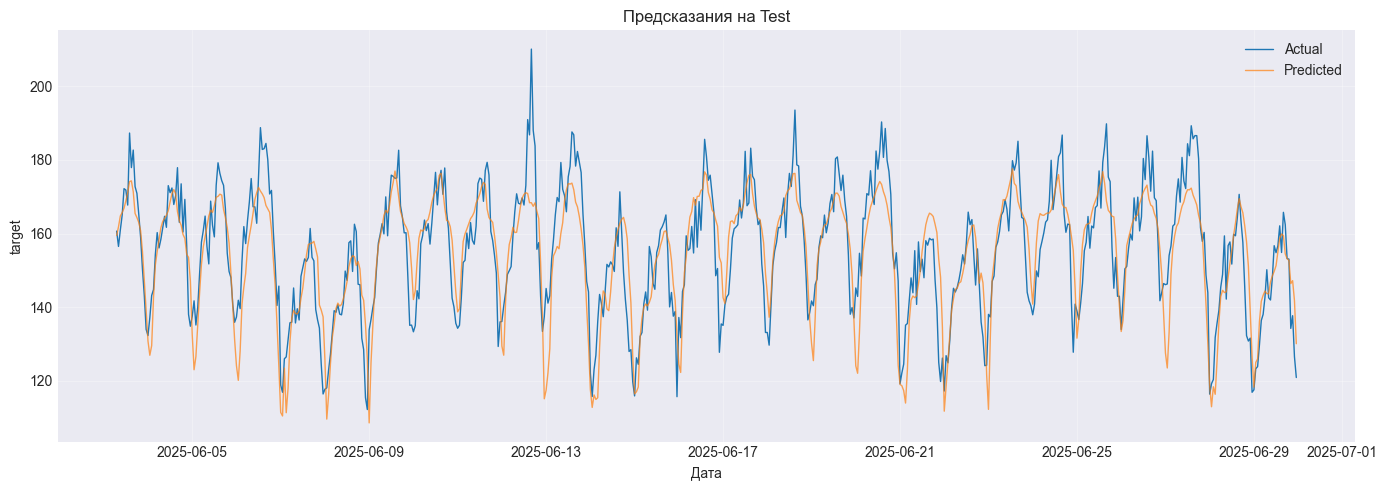

In [16]:
# Визуализация истории обучения и финальная оценка на test
# === Визуализация истории обучения ===
plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss по эпохам')
plt.xlabel('Эпоха')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history['val_rmse'], label='Val RMSE')
plt.plot(history['val_mae'], label='Val MAE')
plt.title('Метрики на Validation')
plt.xlabel('Эпоха')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/training_history.png', dpi=300)
plt.show()

# === Финальная оценка на test ===
print("=== Финальная оценка на Test ===")
criterion = nn.MSELoss()
test_loss, test_rmse, test_mae, test_preds, test_targets = evaluate(
    trained_model, test_loader, criterion, scaler_target
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAE: {test_mae:.4f}")

# График предсказаний на test
plt.figure(figsize=(14, 5))
plt.plot(test['date'].iloc[WINDOW_SIZE:], test_targets, label='Actual', linewidth=1)
plt.plot(test['date'].iloc[WINDOW_SIZE:], test_preds, label='Predicted', linewidth=1, alpha=0.7)
plt.title('Предсказания на Test')
plt.xlabel('Дата')
plt.ylabel('target')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/test_predictions.png', dpi=300)
plt.show()

In [17]:
# === 3.1. Подготовка к экспериментам ===
from sklearn.metrics import mean_absolute_error, mean_squared_error
import json
from datetime import datetime

# Функция для расчёта MAPE
def calculate_mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# Функция для расчёта sMAPE
def calculate_smape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    mask = denominator != 0
    diff = np.abs(y_pred[mask] - y_true[mask]) / denominator[mask]
    return np.mean(diff) * 100

# Функция для расчёта всех метрик
def calculate_all_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = calculate_mape(y_true, y_pred)
    smape = calculate_smape(y_true, y_pred)
    return {'mae': mae, 'rmse': rmse, 'mape': mape, 'smape': smape}

# Функция для записи результатов в runs.csv
def save_to_runs_csv(results_list, filepath='artifacts/runs.csv'):
    import pandas as pd
    df = pd.DataFrame(results_list)
    
    # Если файл существует — дописываем, иначе создаём
    if os.path.exists(filepath):
        existing_df = pd.read_csv(filepath)
        df = pd.concat([existing_df, df], ignore_index=True)
    
    df.to_csv(filepath, index=False)
    print(f"Результаты сохранены в {filepath}")
    return df

print("Функции метрик готовы")

Функции метрик готовы


In [18]:
# === Эксперимент B1: Naive Last ===
print("=== Эксперимент B1: Naive Last ===")

# Прогноз = последнее известное значение из train
last_value = train['target'].iloc[-1]

# Предсказания на validation
val_pred_b1 = np.full(len(val), last_value)
metrics_val_b1 = calculate_all_metrics(val['target'].values, val_pred_b1)

# Предсказания на test
test_pred_b1 = np.full(len(test), last_value)
metrics_test_b1 = calculate_all_metrics(test['target'].values, test_pred_b1)

print(f"Validation MAE: {metrics_val_b1['mae']:.4f}, RMSE: {metrics_val_b1['rmse']:.4f}")
print(f"Test MAE: {metrics_test_b1['mae']:.4f}, RMSE: {metrics_test_b1['rmse']:.4f}")

# Сохранение результата
result_b1 = {
    'experiment_id': 'B1',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset.csv',
    'seed': SEED,
    'split_summary': f'train:{len(train)}|val:{len(val)}|test:{len(test)}',
    'window_size': None,
    'horizon': 1,
    'model_summary': 'Naive Last - прогноз равен последнему значению train',
    'features_summary': 'none',
    'scaler': 'none',
    'optimizer': 'none',
    'lr': None,
    'epochs_trained': 0,
    'best_val_mae': metrics_val_b1['mae'],
    'best_val_rmse': metrics_val_b1['rmse'],
    'best_val_mape': metrics_val_b1['mape'],
    'test_mae': metrics_test_b1['mae'],
    'test_rmse': metrics_test_b1['rmse'],
    'test_mape': metrics_test_b1['mape'],
    'notes': f'sMAPE: {metrics_val_b1["smape"]:.4f}',
    'timestamp': datetime.now().isoformat()
}

print("B1 завершён")

=== Эксперимент B1: Naive Last ===
Validation MAE: 20.3401, RMSE: 24.3643
Test MAE: 23.6670, RMSE: 27.8478
B1 завершён


In [19]:
# === Эксперимент B2: Moving Average ===
print("=== Эксперимент B2: Moving Average ===")

# Окно для скользящего среднего
WINDOW_MA = 7

# Расчёт скользящего среднего на train
train['rolling_ma'] = train['target'].rolling(window=WINDOW_MA).mean()
last_ma_value = train['rolling_ma'].iloc[-1]

# Предсказания на validation
val_pred_b2 = np.full(len(val), last_ma_value)
metrics_val_b2 = calculate_all_metrics(val['target'].values, val_pred_b2)

# Предсказания на test
test_pred_b2 = np.full(len(test), last_ma_value)
metrics_test_b2 = calculate_all_metrics(test['target'].values, test_pred_b2)

print(f"Validation MAE: {metrics_val_b2['mae']:.4f}, RMSE: {metrics_val_b2['rmse']:.4f}")
print(f"Test MAE: {metrics_test_b2['mae']:.4f}, RMSE: {metrics_test_b2['rmse']:.4f}")

# Сохранение результата
result_b2 = {
    'experiment_id': 'B2',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset.csv',
    'seed': SEED,
    'split_summary': f'train:{len(train)}|val:{len(val)}|test:{len(test)}',
    'window_size': WINDOW_MA,
    'horizon': 1,
    'model_summary': f'Moving Average с окном {WINDOW_MA}',
    'features_summary': 'rolling_mean',
    'scaler': 'none',
    'optimizer': 'none',
    'lr': None,
    'epochs_trained': 0,
    'best_val_mae': metrics_val_b2['mae'],
    'best_val_rmse': metrics_val_b2['rmse'],
    'best_val_mape': metrics_val_b2['mape'],
    'test_mae': metrics_test_b2['mae'],
    'test_rmse': metrics_test_b2['rmse'],
    'test_mape': metrics_test_b2['mape'],
    'notes': f'sMAPE: {metrics_val_b2["smape"]:.4f}',
    'timestamp': datetime.now().isoformat()
}

print("B2 завершён")

=== Эксперимент B2: Moving Average ===
Validation MAE: 14.6869, RMSE: 17.6179
Test MAE: 15.8210, RMSE: 19.0403
B2 завершён


In [20]:
# === Эксперимент B3: Ridge на лаговых признаках ===
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

print("=== Эксперимент B3: Ridge Regression ===")

# Признаки (те же что для GRU, без утечки)
FEATURE_COLS_B3 = ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7',
                   'day_of_week', 'month', 'day_of_month']

# Подготовка данных
X_train_b3 = train[FEATURE_COLS_B3].dropna().values
y_train_b3 = train['target'].dropna().values

X_val_b3 = val[FEATURE_COLS_B3].dropna().values
y_val_b3 = val['target'].dropna().values

X_test_b3 = test[FEATURE_COLS_B3].dropna().values
y_test_b3 = test['target'].dropna().values

# Масштабирование (fit только на train)
scaler_b3 = StandardScaler()
X_train_b3_scaled = scaler_b3.fit_transform(X_train_b3)
X_val_b3_scaled = scaler_b3.transform(X_val_b3)
X_test_b3_scaled = scaler_b3.transform(X_test_b3)

# Обучение Ridge
ridge_model = Ridge(alpha=1.0, random_state=SEED)
ridge_model.fit(X_train_b3_scaled, y_train_b3)

# Предсказания на validation
val_pred_b3 = ridge_model.predict(X_val_b3_scaled)
metrics_val_b3 = calculate_all_metrics(y_val_b3, val_pred_b3)

# Предсказания на test
test_pred_b3 = ridge_model.predict(X_test_b3_scaled)
metrics_test_b3 = calculate_all_metrics(y_test_b3, test_pred_b3)

print(f"Validation MAE: {metrics_val_b3['mae']:.4f}, RMSE: {metrics_val_b3['rmse']:.4f}")
print(f"Test MAE: {metrics_test_b3['mae']:.4f}, RMSE: {metrics_test_b3['rmse']:.4f}")

# Сохранение результата
result_b3 = {
    'experiment_id': 'B3',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset.csv',
    'seed': SEED,
    'split_summary': f'train:{len(X_train_b3)}|val:{len(X_val_b3)}|test:{len(X_test_b3)}',
    'window_size': None,
    'horizon': 1,
    'model_summary': 'Ridge Regression (alpha=1.0)',
    'features_summary': 'lag_1, lag_7, lag_14, rolling_mean_7, rolling_std_7, day_of_week, month, day_of_month',
    'scaler': 'StandardScaler',
    'optimizer': 'none',
    'lr': None,
    'epochs_trained': 0,
    'best_val_mae': metrics_val_b3['mae'],
    'best_val_rmse': metrics_val_b3['rmse'],
    'best_val_mape': metrics_val_b3['mape'],
    'test_mae': metrics_test_b3['mae'],
    'test_rmse': metrics_test_b3['rmse'],
    'test_mape': metrics_test_b3['mape'],
    'notes': f'sMAPE: {metrics_val_b3["smape"]:.4f}',
    'timestamp': datetime.now().isoformat()
}

print("B3 завершён")

=== Эксперимент B3: Ridge Regression ===
Validation MAE: 6.3493, RMSE: 7.9383
Test MAE: 6.0205, RMSE: 7.6970
B3 завершён


In [21]:
# === Эксперимент R1: GRU Forecast ===
print("=== Эксперимент R1: GRU Forecast ===")

# Используем уже обученную модель из части 2.3.6
# Оценка на validation (уже есть в history)
val_loss, val_rmse, val_mae, val_preds, val_targets = evaluate(
    trained_model, val_loader, nn.MSELoss(), scaler_target
)
val_mape = calculate_mape(val_targets, val_preds)
val_smape = calculate_smape(val_targets, val_preds)

# Оценка на test (ФИНАЛЬНАЯ, один раз!)
test_loss, test_rmse, test_mae, test_preds, test_targets = evaluate(
    trained_model, test_loader, nn.MSELoss(), scaler_target
)
test_mape = calculate_mape(test_targets, test_preds)
test_smape = calculate_smape(test_targets, test_preds)

print(f"Validation MAE: {val_mae:.4f}, RMSE: {val_rmse:.4f}, MAPE: {val_mape:.4f}")
print(f"Test MAE: {test_mae:.4f}, RMSE: {test_rmse:.4f}, MAPE: {test_mape:.4f}")

# Сохранение результата
result_r1 = {
    'experiment_id': 'R1',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset.csv',
    'seed': SEED,
    'split_summary': f'train:{len(train_dataset)}|val:{len(val_dataset)}|test:{len(test_dataset)}',
    'window_size': WINDOW_SIZE,
    'horizon': 1,
    'model_summary': f'GRU(hidden_size={HIDDEN_SIZE}, num_layers={NUM_LAYERS})',
    'features_summary': 'lag_1, lag_7, lag_14, rolling_mean_7, rolling_std_7, day_of_week, month, day_of_month',
    'scaler': 'StandardScaler',
    'optimizer': 'Adam',
    'lr': LEARNING_RATE,
    'epochs_trained': EPOCHS,
    'best_val_mae': val_mae,
    'best_val_rmse': val_rmse,
    'best_val_mape': val_mape,
    'test_mae': test_mae,
    'test_rmse': test_rmse,
    'test_mape': test_mape,
    'notes': f'sMAPE_val:{val_smape:.4f}|sMAPE_test:{test_smape:.4f}',
    'timestamp': datetime.now().isoformat()
}

print("R1 завершён")

=== Эксперимент R1: GRU Forecast ===
Validation MAE: 6.2053, RMSE: 8.1340, MAPE: 4.1872
Test MAE: 7.2038, RMSE: 9.3849, MAPE: 4.7464
R1 завершён


In [22]:
# === Сохранение всех результатов в runs.csv ===
all_results = [result_b1, result_b2, result_b3, result_r1]
runs_df = save_to_runs_csv(all_results, filepath='artifacts/runs.csv')

# Отображение таблицы
print("\n=== Сводная таблица результатов ===")
display_cols = ['experiment_id', 'best_val_mae', 'best_val_rmse', 'test_mae', 'test_rmse']
print(runs_df[display_cols].to_string(index=False))

# Выбор лучшей модели по validation MAE
best_model_row = runs_df.loc[runs_df['best_val_mae'].idxmin()]
best_experiment_id = best_model_row['experiment_id']
print(f"\nЛучшая модель по validation MAE: {best_experiment_id}")

# Сохранение лучшей модели GRU (если R1 лучшая или для артефакта)
torch.save(trained_model.state_dict(), 'artifacts/best_gru.pt')
print("Модель сохранена: artifacts/best_gru.pt")

# Сохранение конфига лучшей модели
gru_config = {
    'experiment_id': 'R1',
    'architecture': 'GRU',
    'input_size': INPUT_SIZE,
    'hidden_size': HIDDEN_SIZE,
    'num_layers': NUM_LAYERS,
    'output_size': OUTPUT_SIZE,
    'window_size': WINDOW_SIZE,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'epochs': EPOCHS,
    'seed': SEED,
    'device': str(device),
    'scaler_type': 'StandardScaler',
    'feature_columns': FEATURE_COLS,
    'timestamp': datetime.now().isoformat()
}

with open('artifacts/best_gru_config.json', 'w', encoding='utf-8') as f:
    json.dump(gru_config, f, indent=2, ensure_ascii=False)
print("Конфиг сохранён: artifacts/best_gru_config.json")

Результаты сохранены в artifacts/runs.csv

=== Сводная таблица результатов ===
experiment_id  best_val_mae  best_val_rmse  test_mae  test_rmse
           B1     20.340093      24.364325 23.666960  27.847792
           B2     14.686927      17.617873 15.821012  19.040319
           B3      6.349328       7.938286  6.020544   7.696996
           R1      6.205291       8.134026  7.203829   9.384918

Лучшая модель по validation MAE: R1
Модель сохранена: artifacts/best_gru.pt
Конфиг сохранён: artifacts/best_gru_config.json


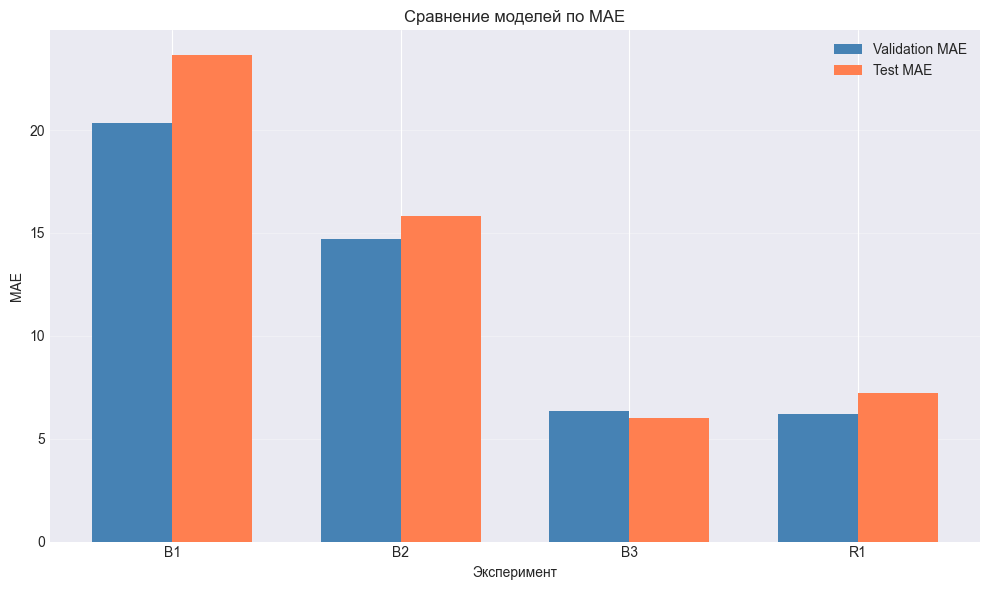

Сохранено: artifacts/figures/baselines_compare.png


In [23]:
# Визуализация — сравнение baseline (baselines_compare.png)
# === figures/baselines_compare.png ===
plt.figure(figsize=(10, 6))

experiments = ['B1', 'B2', 'B3', 'R1']
val_maes = [metrics_val_b1['mae'], metrics_val_b2['mae'], 
            metrics_val_b3['mae'], val_mae]
test_maes = [metrics_test_b1['mae'], metrics_test_b2['mae'], 
             metrics_test_b3['mae'], test_mae]

x = np.arange(len(experiments))
width = 0.35

plt.bar(x - width/2, val_maes, width, label='Validation MAE', color='steelblue')
plt.bar(x + width/2, test_maes, width, label='Test MAE', color='coral')

plt.xlabel('Эксперимент')
plt.ylabel('MAE')
plt.title('Сравнение моделей по MAE')
plt.xticks(x, experiments)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('artifacts/figures/baselines_compare.png', dpi=300)
plt.show()

print("Сохранено: artifacts/figures/baselines_compare.png")

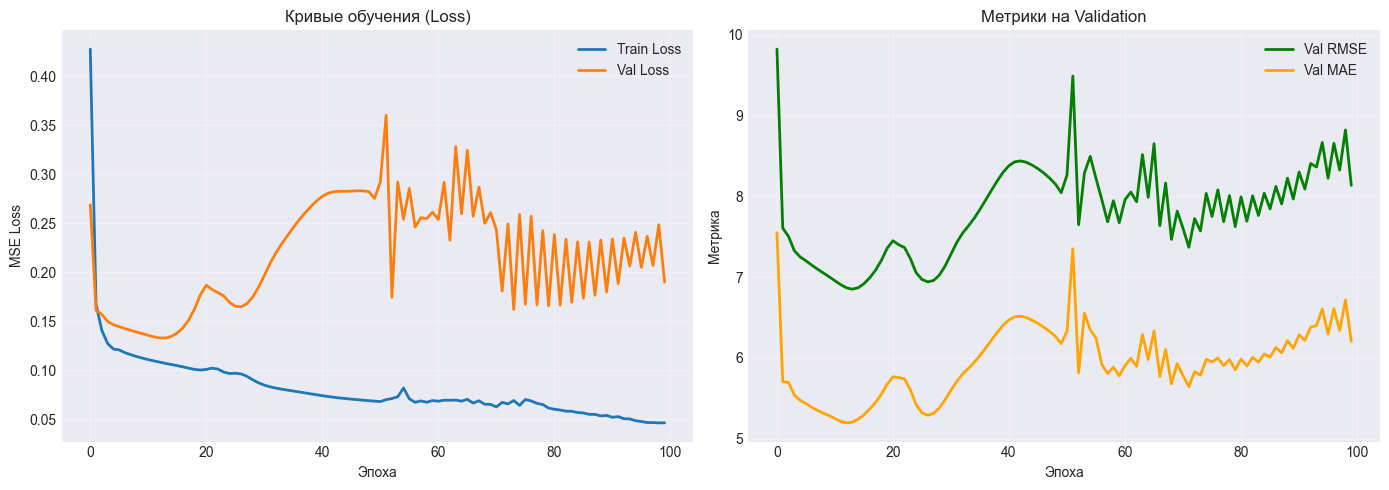

Сохранено: artifacts/figures/gru_learning_curves.png


In [24]:
# Визуализация — кривые обучения GRU (gru_learning_curves.png)
# === figures/gru_learning_curves.png ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Кривые обучения (Loss)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['val_rmse'], label='Val RMSE', linewidth=2, color='green')
axes[1].plot(history['val_mae'], label='Val MAE', linewidth=2, color='orange')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Метрика')
axes[1].set_title('Метрики на Validation')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/gru_learning_curves.png', dpi=300)
plt.show()

print("Сохранено: artifacts/figures/gru_learning_curves.png")

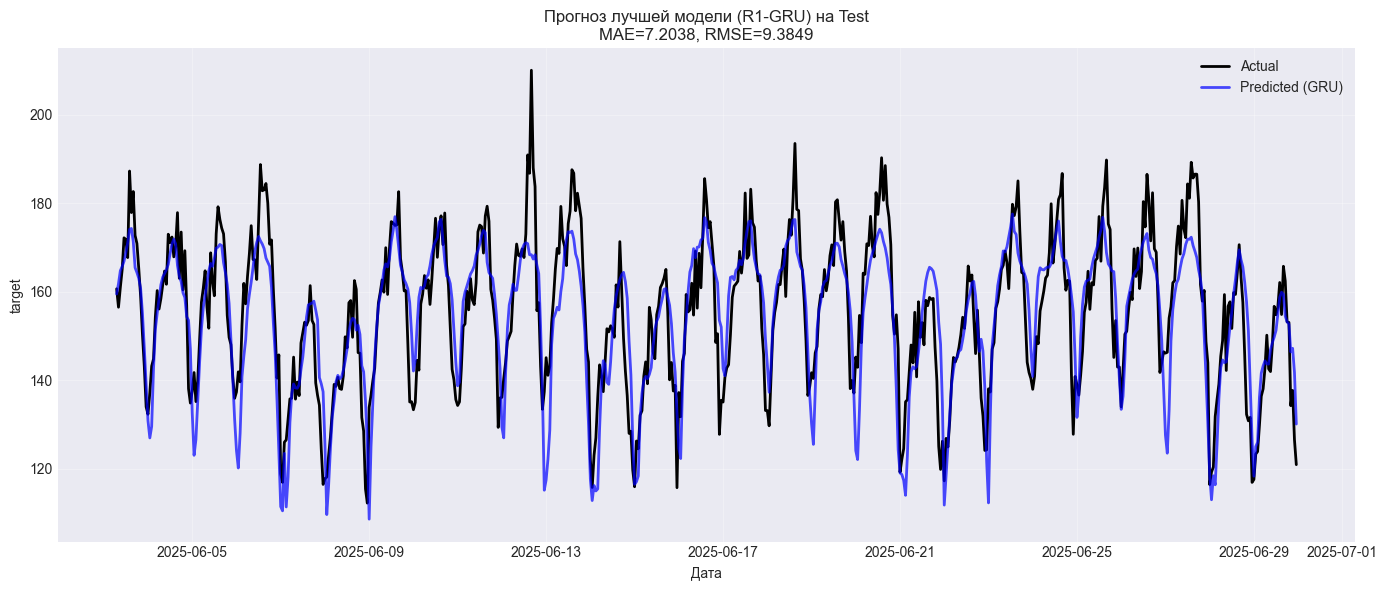

Сохранено: artifacts/figures/best_forecast_test.png


In [25]:
# Визуализация — лучший прогноз на test (best_forecast_test.png)
# === figures/best_forecast_test.png ===
plt.figure(figsize=(14, 6))

# Для R1 (GRU)
plt.plot(test['date'].iloc[WINDOW_SIZE:].reset_index(drop=True), 
         test_targets, label='Actual', linewidth=2, color='black')
plt.plot(test['date'].iloc[WINDOW_SIZE:].reset_index(drop=True), 
         test_preds, label='Predicted (GRU)', linewidth=2, color='blue', alpha=0.7)

plt.xlabel('Дата')
plt.ylabel('target')
plt.title(f'Прогноз лучшей модели (R1-GRU) на Test\nMAE={test_mae:.4f}, RMSE={test_rmse:.4f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/best_forecast_test.png', dpi=300)
plt.show()

print("Сохранено: artifacts/figures/best_forecast_test.png")

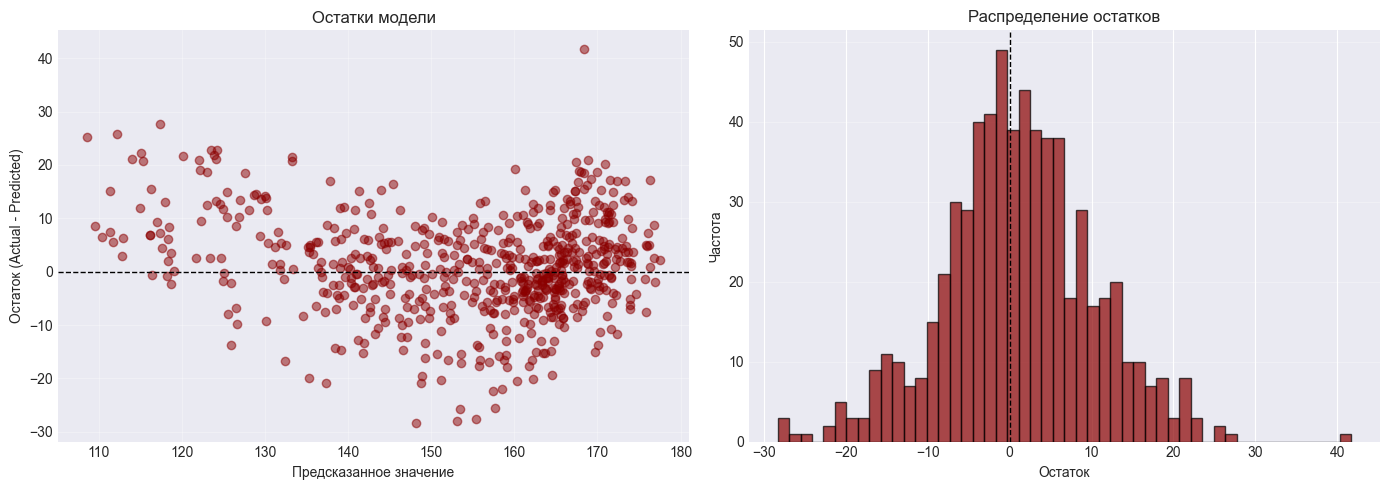

Сохранено: artifacts/figures/residuals_best.png


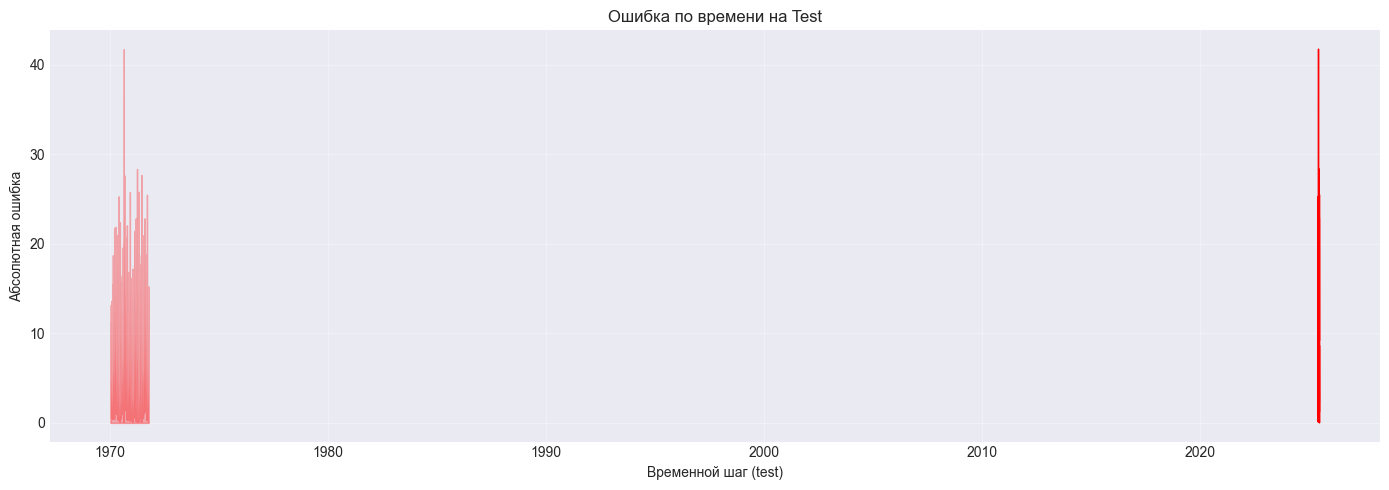

Сохранено: artifacts/figures/error_by_time.png


In [26]:
# Дополнительные визуализации (residuals, error_by_time)
# === figures/residuals_best.png ===
residuals = np.array(test_targets) - np.array(test_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(test_preds, residuals, alpha=0.5, color='darkred')
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[0].set_xlabel('Предсказанное значение')
axes[0].set_ylabel('Остаток (Actual - Predicted)')
axes[0].set_title('Остатки модели')
axes[0].grid(True, alpha=0.3)

axes[1].hist(residuals, bins=50, color='darkred', edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Остаток')
axes[1].set_ylabel('Частота')
axes[1].set_title('Распределение остатков')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('artifacts/figures/residuals_best.png', dpi=300)
plt.show()

print("Сохранено: artifacts/figures/residuals_best.png")

# === figures/error_by_time.png ===
error_by_time = np.abs(residuals)

plt.figure(figsize=(14, 5))
plt.plot(test['date'].iloc[WINDOW_SIZE:].reset_index(drop=True), error_by_time, 
         linewidth=1, color='red')
plt.fill_between(range(len(error_by_time)), error_by_time, alpha=0.3, color='red')
plt.xlabel('Временной шаг (test)')
plt.ylabel('Абсолютная ошибка')
plt.title('Ошибка по времени на Test')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/error_by_time.png', dpi=300)
plt.show()

print("Сохранено: artifacts/figures/error_by_time.png")

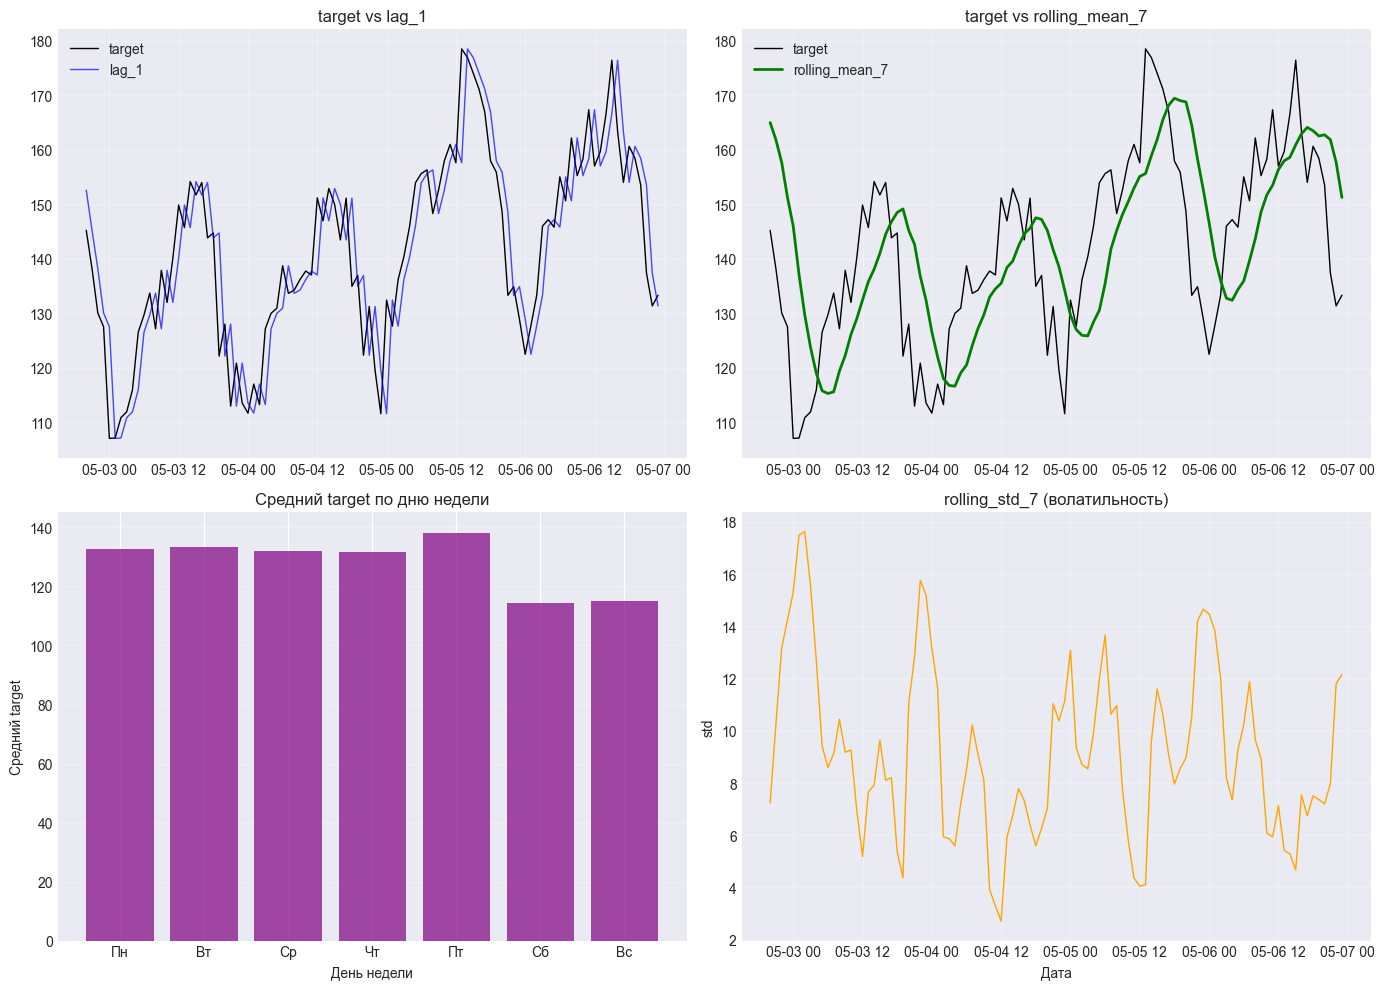

Сохранено: artifacts/figures/feature_examples.png


In [27]:
# figures/feature_examples.png (примеры признаков)
# === figures/feature_examples.png ===
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# lag_1
axes[0, 0].plot(train['date'].iloc[-100:], train['target'].iloc[-100:], 
                label='target', linewidth=1, color='black')
axes[0, 0].plot(train['date'].iloc[-100:], train['lag_1'].iloc[-100:], 
                label='lag_1', linewidth=1, color='blue', alpha=0.7)
axes[0, 0].set_title('target vs lag_1')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# rolling_mean_7
axes[0, 1].plot(train['date'].iloc[-100:], train['target'].iloc[-100:], 
                label='target', linewidth=1, color='black')
axes[0, 1].plot(train['date'].iloc[-100:], train['rolling_mean_7'].iloc[-100:], 
                label='rolling_mean_7', linewidth=2, color='green')
axes[0, 1].set_title('target vs rolling_mean_7')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# day_of_week
axes[1, 0].bar(range(7), train.groupby('day_of_week')['target'].mean().values, 
               color='purple', alpha=0.7)
axes[1, 0].set_xticks(range(7))
axes[1, 0].set_xticklabels(['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'])
axes[1, 0].set_xlabel('День недели')
axes[1, 0].set_ylabel('Средний target')
axes[1, 0].set_title('Средний target по дню недели')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# rolling_std_7
axes[1, 1].plot(train['date'].iloc[-100:], train['rolling_std_7'].iloc[-100:], 
                linewidth=1, color='orange')
axes[1, 1].set_title('rolling_std_7 (волатильность)')
axes[1, 1].set_xlabel('Дата')
axes[1, 1].set_ylabel('std')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/feature_examples.png', dpi=300)
plt.show()

print("Сохранено: artifacts/figures/feature_examples.png")

In [28]:
# === Финальная проверка всех артефактов ===
print("=== Проверка артефактов ===")

required_files = [
    'artifacts/runs.csv',
    'artifacts/best_gru.pt',
    'artifacts/best_gru_config.json',
    'artifacts/figures/series_split.png',  # уже есть из ячейки 3
    'artifacts/figures/baselines_compare.png',
    'artifacts/figures/gru_learning_curves.png',
    'artifacts/figures/best_forecast_test.png',
    'artifacts/figures/residuals_best.png',
    'artifacts/figures/error_by_time.png',
    'artifacts/figures/feature_examples.png'
]

for filepath in required_files:
    if os.path.exists(filepath):
        size = os.path.getsize(filepath)
        print(f"[OK] {filepath} ({size} байт)")
    else:
        print(f"[MISSING] {filepath}")

print("\n=== Все эксперименты завершены ===")

=== Проверка артефактов ===
[OK] artifacts/runs.csv (1575 байт)
[OK] artifacts/best_gru.pt (160981 байт)
[OK] artifacts/best_gru_config.json (514 байт)
[MISSING] artifacts/figures/series_split.png
[OK] artifacts/figures/baselines_compare.png (65761 байт)
[OK] artifacts/figures/gru_learning_curves.png (374569 байт)
[OK] artifacts/figures/best_forecast_test.png (626340 байт)
[OK] artifacts/figures/residuals_best.png (527022 байт)
[OK] artifacts/figures/error_by_time.png (100194 байт)
[OK] artifacts/figures/feature_examples.png (697051 байт)

=== Все эксперименты завершены ===


In [29]:
# === Опционально 1: Сравнение GRU и LSTM ===
print("=== Эксперимент R2: LSTM Forecast ===")

# LSTM модель
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

# Инициализация LSTM
LSTM_HIDDEN_SIZE = 64
LSTM_NUM_LAYERS = 2

lstm_model = LSTMModel(INPUT_SIZE, LSTM_HIDDEN_SIZE, LSTM_NUM_LAYERS, OUTPUT_SIZE).to(device)

# Функция обучения (аналогичная GRU)
def train_model_generic(model, train_loader, val_loader, epochs, lr, scaler_target, model_name):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_rmse': [],
        'val_mae': []
    }
    
    best_val_loss = float('inf')
    best_model_state = None
    
    print(f"Начало обучения {model_name}")
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        avg_train_loss = train_loss / len(train_loader)
        val_loss, val_rmse, val_mae, _, _ = evaluate(model, val_loader, criterion, scaler_target)
        
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(val_loss)
        history['val_rmse'].append(val_rmse)
        history['val_mae'].append(val_mae)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f}")
    
    model.load_state_dict(best_model_state)
    print(f"Обучение {model_name} завершено. Лучший Val Loss: {best_val_loss:.4f}")
    
    return history, model

# Обучение LSTM
LSTM_EPOCHS = 100
LSTM_LR = 0.001

lstm_history, trained_lstm = train_model_generic(
    lstm_model, train_loader, val_loader, LSTM_EPOCHS, LSTM_LR, scaler_target, 'LSTM'
)

# Оценка LSTM
val_loss_lstm, val_rmse_lstm, val_mae_lstm, val_preds_lstm, val_targets_lstm = evaluate(
    trained_lstm, val_loader, nn.MSELoss(), scaler_target
)
val_mape_lstm = calculate_mape(val_targets_lstm, val_preds_lstm)

test_loss_lstm, test_rmse_lstm, test_mae_lstm, test_preds_lstm, test_targets_lstm = evaluate(
    trained_lstm, test_loader, nn.MSELoss(), scaler_target
)
test_mape_lstm = calculate_mape(test_targets_lstm, test_preds_lstm)

print(f"LSTM Validation MAE: {val_mae_lstm:.4f}, Test MAE: {test_mae_lstm:.4f}")

# Сохранение результата
result_r2 = {
    'experiment_id': 'R2',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset.csv',
    'seed': SEED,
    'split_summary': f'train:{len(train_dataset)}|val:{len(val_dataset)}|test:{len(test_dataset)}',
    'window_size': WINDOW_SIZE,
    'horizon': 1,
    'model_summary': f'LSTM(hidden_size={LSTM_HIDDEN_SIZE}, num_layers={LSTM_NUM_LAYERS})',
    'features_summary': 'lag_1, lag_7, lag_14, rolling_mean_7, rolling_std_7, day_of_week, month, day_of_month',
    'scaler': 'StandardScaler',
    'optimizer': 'Adam',
    'lr': LSTM_LR,
    'epochs_trained': LSTM_EPOCHS,
    'best_val_mae': val_mae_lstm,
    'best_val_rmse': val_rmse_lstm,
    'best_val_mape': val_mape_lstm,
    'test_mae': test_mae_lstm,
    'test_rmse': test_rmse_lstm,
    'test_mape': test_mape_lstm,
    'notes': 'Optional: GRU vs LSTM comparison',
    'timestamp': datetime.now().isoformat()
}

# Сохранение модели LSTM
torch.save(trained_lstm.state_dict(), 'artifacts/best_lstm.pt')
print("Модель LSTM сохранена: artifacts/best_lstm.pt")

=== Эксперимент R2: LSTM Forecast ===
Начало обучения LSTM
Epoch 10/100 | Train Loss: 0.1101 | Val Loss: 0.1516
Epoch 20/100 | Train Loss: 0.0893 | Val Loss: 0.2203
Epoch 30/100 | Train Loss: 0.0754 | Val Loss: 0.2444
Epoch 40/100 | Train Loss: 0.0692 | Val Loss: 0.1944
Epoch 50/100 | Train Loss: 0.0666 | Val Loss: 0.1980
Epoch 60/100 | Train Loss: 0.0626 | Val Loss: 0.1862
Epoch 70/100 | Train Loss: 0.0598 | Val Loss: 0.1885
Epoch 80/100 | Train Loss: 0.0515 | Val Loss: 0.2213
Epoch 90/100 | Train Loss: 0.0486 | Val Loss: 0.2067
Epoch 100/100 | Train Loss: 0.0459 | Val Loss: 0.2181
Обучение LSTM завершено. Лучший Val Loss: 0.1516
LSTM Validation MAE: 6.7723, Test MAE: 6.5816
Модель LSTM сохранена: artifacts/best_lstm.pt


In [30]:
# === Опционально 2: Подбор window_size ===
print("=== Эксперимент R3: Tuning Window Size ===")

window_sizes = [3, 7, 14]
window_results = []

for ws in window_sizes:
    print(f"\n--- Window Size: {ws} ---")
    
    # Создание dataset с новым window_size
    ws_dataset = TimeSeriesDataset(X_train_scaled, y_train_scaled, ws)
    ws_val_dataset = TimeSeriesDataset(X_val_scaled, y_val_scaled, ws)
    ws_test_dataset = TimeSeriesDataset(X_test_scaled, y_test_scaled, ws)
    
    ws_train_loader = DataLoader(ws_dataset, batch_size=BATCH_SIZE, shuffle=False)
    ws_val_loader = DataLoader(ws_val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    ws_test_loader = DataLoader(ws_test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    # Модель с новым input_size (зависит от window_size через последовательности)
    ws_model = GRUModel(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, OUTPUT_SIZE).to(device)
    
    # Быстрое обучение (50 эпох для экономии времени)
    ws_history, ws_trained = train_model_generic(
        ws_model, ws_train_loader, ws_val_loader, 50, LEARNING_RATE, scaler_target, f'GRU_ws{ws}'
    )
    
    # Оценка
    _, _, ws_val_mae, ws_val_preds, ws_val_targets = evaluate(
        ws_trained, ws_val_loader, nn.MSELoss(), scaler_target
    )
    _, _, ws_test_mae, ws_test_preds, ws_test_targets = evaluate(
        ws_trained, ws_test_loader, nn.MSELoss(), scaler_target
    )
    
    window_results.append({
        'window_size': ws,
        'val_mae': ws_val_mae,
        'test_mae': ws_test_mae
    })
    
    print(f"Window {ws}: Val MAE={ws_val_mae:.4f}, Test MAE={ws_test_mae:.4f}")

# Сохранение результата
best_ws = min(window_results, key=lambda x: x['val_mae'])
result_r3 = {
    'experiment_id': 'R3',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset.csv',
    'seed': SEED,
    'split_summary': f'train:{len(train_dataset)}|val:{len(val_dataset)}|test:{len(test_dataset)}',
    'window_size': f'{window_sizes} (best: {best_ws["window_size"]})',
    'horizon': 1,
    'model_summary': f'GRU window_size tuning ({len(window_sizes)} variants)',
    'features_summary': 'lag_1, lag_7, lag_14, rolling_mean_7, rolling_std_7, day_of_week, month, day_of_month',
    'scaler': 'StandardScaler',
    'optimizer': 'Adam',
    'lr': LEARNING_RATE,
    'epochs_trained': 50,
    'best_val_mae': best_ws['val_mae'],
    'best_val_rmse': None,
    'best_val_mape': None,
    'test_mae': best_ws['test_mae'],
    'test_rmse': None,
    'test_mape': None,
    'notes': f'Optional: Best window_size={best_ws["window_size"]}',
    'timestamp': datetime.now().isoformat()
}

print(f"\nЛучший window_size: {best_ws['window_size']} (Val MAE={best_ws['val_mae']:.4f})")

=== Эксперимент R3: Tuning Window Size ===

--- Window Size: 3 ---
Начало обучения GRU_ws3
Epoch 10/50 | Train Loss: 0.1343 | Val Loss: 0.2146
Epoch 20/50 | Train Loss: 0.1157 | Val Loss: 0.1840
Epoch 30/50 | Train Loss: 0.0997 | Val Loss: 0.2049
Epoch 40/50 | Train Loss: 0.0889 | Val Loss: 0.2094
Epoch 50/50 | Train Loss: 0.0798 | Val Loss: 0.2158
Обучение GRU_ws3 завершено. Лучший Val Loss: 0.1839
Window 3: Val MAE=6.4802, Test MAE=8.0922

--- Window Size: 7 ---
Начало обучения GRU_ws7
Epoch 10/50 | Train Loss: 0.1091 | Val Loss: 0.1341
Epoch 20/50 | Train Loss: 0.0975 | Val Loss: 0.1309
Epoch 30/50 | Train Loss: 0.0886 | Val Loss: 0.2037
Epoch 40/50 | Train Loss: 0.0776 | Val Loss: 0.2839
Epoch 50/50 | Train Loss: 0.0700 | Val Loss: 0.3380
Обучение GRU_ws7 завершено. Лучший Val Loss: 0.1289
Window 7: Val MAE=6.7191, Test MAE=13.7461

--- Window Size: 14 ---
Начало обучения GRU_ws14
Epoch 10/50 | Train Loss: 0.1013 | Val Loss: 0.1405
Epoch 20/50 | Train Loss: 0.0878 | Val Loss: 0.190

In [31]:
# === Опционально 3: Random Forest ===
from sklearn.ensemble import RandomForestRegressor

print("=== Эксперимент B4: Random Forest ===")

# Подготовка данных (те же признаки что для Ridge)
X_train_rf = train[FEATURE_COLS_B3].dropna().values
y_train_rf = train['target'].dropna().values

X_val_rf = val[FEATURE_COLS_B3].dropna().values
y_val_rf = val['target'].dropna().values

X_test_rf = test[FEATURE_COLS_B3].dropna().values
y_test_rf = test['target'].dropna().values

# Масштабирование (для RF не обязательно, но для консистентности)
scaler_rf = StandardScaler()
X_train_rf_scaled = scaler_rf.fit_transform(X_train_rf)
X_val_rf_scaled = scaler_rf.transform(X_val_rf)
X_test_rf_scaled = scaler_rf.transform(X_test_rf)

# Обучение Random Forest
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=SEED,
    n_jobs=-1
)
rf_model.fit(X_train_rf_scaled, y_train_rf)

# Предсказания
val_pred_rf = rf_model.predict(X_val_rf_scaled)
metrics_val_rf = calculate_all_metrics(y_val_rf, val_pred_rf)

test_pred_rf = rf_model.predict(X_test_rf_scaled)
metrics_test_rf = calculate_all_metrics(y_test_rf, test_pred_rf)

print(f"Validation MAE: {metrics_val_rf['mae']:.4f}, RMSE: {metrics_val_rf['rmse']:.4f}")
print(f"Test MAE: {metrics_test_rf['mae']:.4f}, RMSE: {metrics_test_rf['rmse']:.4f}")

# Сохранение результата
result_b4 = {
    'experiment_id': 'B4',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset.csv',
    'seed': SEED,
    'split_summary': f'train:{len(X_train_rf)}|val:{len(X_val_rf)}|test:{len(X_test_rf)}',
    'window_size': None,
    'horizon': 1,
    'model_summary': 'RandomForest(n_estimators=100, max_depth=10)',
    'features_summary': 'lag_1, lag_7, lag_14, rolling_mean_7, rolling_std_7, day_of_week, month, day_of_month',
    'scaler': 'StandardScaler',
    'optimizer': 'none',
    'lr': None,
    'epochs_trained': 0,
    'best_val_mae': metrics_val_rf['mae'],
    'best_val_rmse': metrics_val_rf['rmse'],
    'best_val_mape': metrics_val_rf['mape'],
    'test_mae': metrics_test_rf['mae'],
    'test_rmse': metrics_test_rf['rmse'],
    'test_mape': metrics_test_rf['mape'],
    'notes': 'Optional: Tree-based ensemble comparison',
    'timestamp': datetime.now().isoformat()
}

print("B4 завершён")

=== Эксперимент B4: Random Forest ===
Validation MAE: 7.6045, RMSE: 9.4572
Test MAE: 9.0869, RMSE: 11.0452
B4 завершён


=== Анализ ошибок на характерных участках ===

=== Характеристика участков ===
Сегмент 1: Mean Error=6.5353, Std Error=5.0609, Max Error=21.8800, Target Volatility=17.1044
Сегмент 2: Mean Error=7.9374, Std Error=6.7311, Max Error=41.7233, Target Volatility=16.7908
Сегмент 3: Mean Error=6.8809, Std Error=5.6200, Max Error=25.7838, Target Volatility=16.4684
Сегмент 4: Mean Error=7.2252, Std Error=6.4757, Max Error=28.3464, Target Volatility=16.8498
Сегмент 5: Mean Error=7.4386, Std Error=5.9438, Max Error=27.6800, Target Volatility=17.7936

Лучший сегмент: 1 (Mean Error=6.5353)
Худший сегмент: 2 (Mean Error=7.9374)


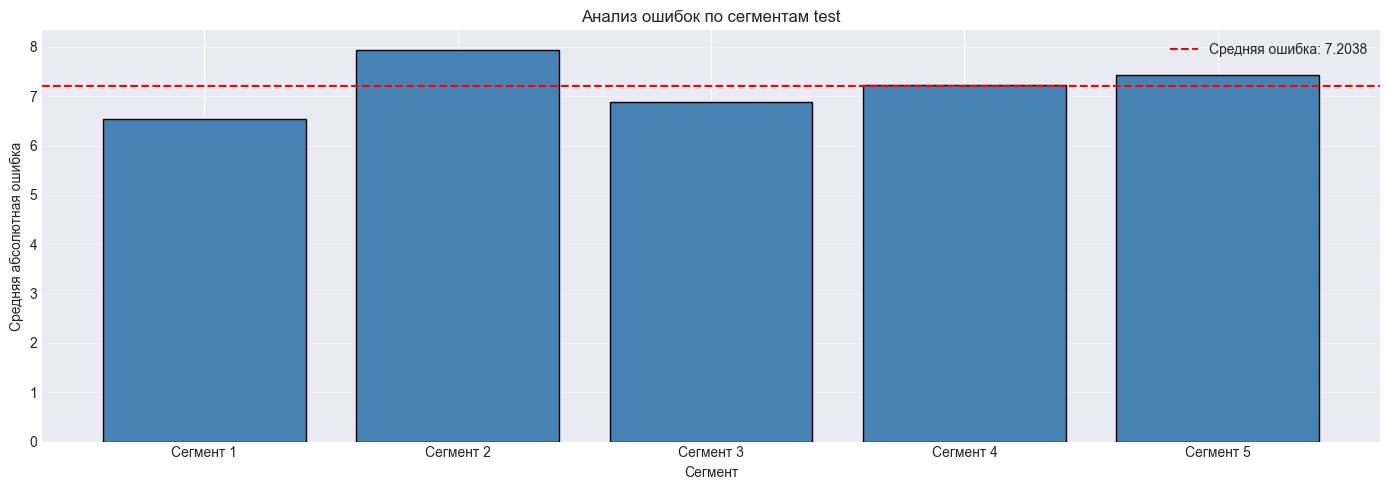

Сохранено: artifacts/figures/error_by_segment.png


In [32]:
# === Опционально 4: Анализ ошибок на 3-5 характерных участках test ===
print("=== Анализ ошибок на характерных участках ===")

# Расчёт абсолютных ошибок
abs_errors = np.abs(np.array(test_targets) - np.array(test_preds))

# Нахождение участков с разными типами ошибок
n_segments = 5
segment_length = len(abs_errors) // n_segments

segments_analysis = []

for i in range(n_segments):
    start_idx = i * segment_length
    end_idx = (i + 1) * segment_length if i < n_segments - 1 else len(abs_errors)
    
    segment_errors = abs_errors[start_idx:end_idx]
    segment_targets = test_targets[start_idx:end_idx]
    segment_preds = test_preds[start_idx:end_idx]
    
    segments_analysis.append({
        'segment': i + 1,
        'start_idx': start_idx,
        'end_idx': end_idx,
        'mean_error': np.mean(segment_errors),
        'std_error': np.std(segment_errors),
        'max_error': np.max(segment_errors),
        'mean_target': np.mean(segment_targets),
        'target_volatility': np.std(segment_targets)
    })

# Вывод анализа
print("\n=== Характеристика участков ===")
for seg in segments_analysis:
    print(f"Сегмент {seg['segment']}: Mean Error={seg['mean_error']:.4f}, "
          f"Std Error={seg['std_error']:.4f}, Max Error={seg['max_error']:.4f}, "
          f"Target Volatility={seg['target_volatility']:.4f}")

# Нахождение лучшего и худшего сегментов
best_segment = min(segments_analysis, key=lambda x: x['mean_error'])
worst_segment = max(segments_analysis, key=lambda x: x['mean_error'])

print(f"\nЛучший сегмент: {best_segment['segment']} (Mean Error={best_segment['mean_error']:.4f})")
print(f"Худший сегмент: {worst_segment['segment']} (Mean Error={worst_segment['mean_error']:.4f})")

# Визуализация ошибок по сегментам
plt.figure(figsize=(14, 5))
segment_means = [s['mean_error'] for s in segments_analysis]
segment_names = [f"Сегмент {s['segment']}" for s in segments_analysis]

plt.bar(segment_names, segment_means, color='steelblue', edgecolor='black')
plt.axhline(y=np.mean(abs_errors), color='red', linestyle='--', label=f'Средняя ошибка: {np.mean(abs_errors):.4f}')
plt.xlabel('Сегмент')
plt.ylabel('Средняя абсолютная ошибка')
plt.title('Анализ ошибок по сегментам test')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('artifacts/figures/error_by_segment.png', dpi=300)
plt.show()

print("Сохранено: artifacts/figures/error_by_segment.png")

=== Бонус: Time Series Classification ===
TSC Accuracy: 0.9500

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95        30
           1       0.91      1.00      0.95        30

    accuracy                           0.95        60
   macro avg       0.95      0.95      0.95        60
weighted avg       0.95      0.95      0.95        60



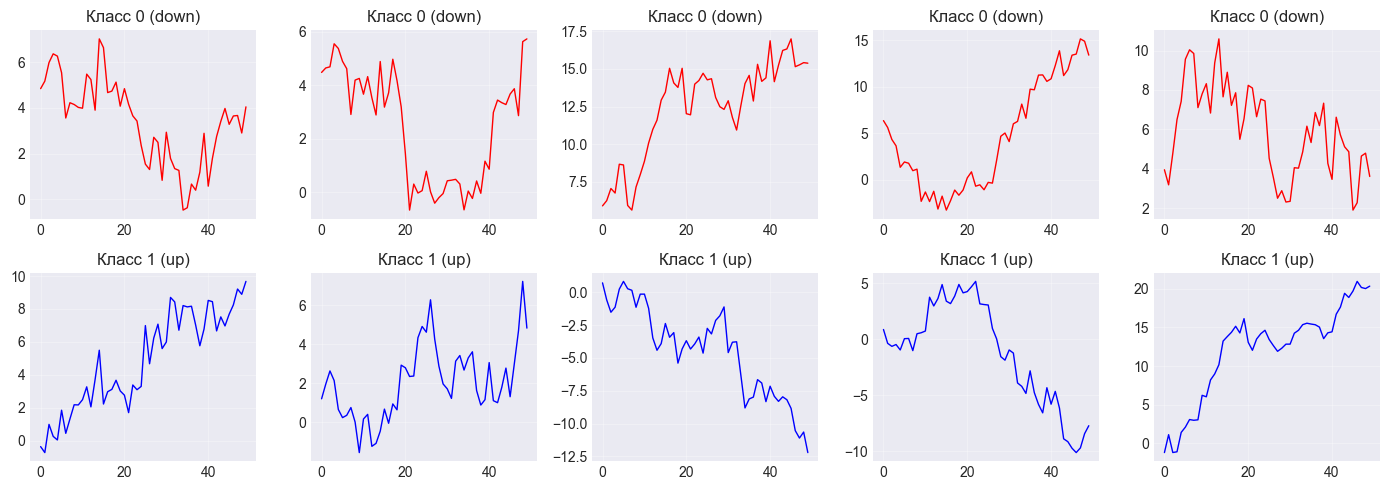

Сохранено: artifacts/figures/tsc_examples.png
TSC бонус завершён


In [33]:
# === Опционально 5: TSC бонус — Классификация временных рядов ===
print("=== Бонус: Time Series Classification ===")

# Создаём синтетический датасет для классификации
# Класс 0: ряд с трендом вниз, Класс 1: ряд с трендом вверх

def generate_tsc_sample(length=50, trend_type='up'):
    np.random.seed(random.randint(0, 10000))
    base = np.random.randn(length).cumsum()
    if trend_type == 'up':
        trend = np.linspace(0, 5, length)
    else:
        trend = np.linspace(5, 0, length)
    return base + trend + np.random.randn(length) * 0.5

# Генерация данных
N_SAMPLES_PER_CLASS = 100
SEQUENCE_LENGTH = 50

X_tsc = []
y_tsc = []

for _ in range(N_SAMPLES_PER_CLASS):
    X_tsc.append(generate_tsc_sample(SEQUENCE_LENGTH, 'up'))
    y_tsc.append(1)

for _ in range(N_SAMPLES_PER_CLASS):
    X_tsc.append(generate_tsc_sample(SEQUENCE_LENGTH, 'down'))
    y_tsc.append(0)

X_tsc = np.array(X_tsc)
y_tsc = np.array(y_tsc)

# Разбиение на train/test для TSC
from sklearn.model_selection import train_test_split

X_tsc_train, X_tsc_test, y_tsc_train, y_tsc_test = train_test_split(
    X_tsc, y_tsc, test_size=0.3, random_state=SEED, stratify=y_tsc
)

# Масштабирование
scaler_tsc = StandardScaler()
X_tsc_train_scaled = scaler_tsc.fit_transform(X_tsc_train)
X_tsc_test_scaled = scaler_tsc.transform(X_tsc_test)

# Простая модель для классификации (Logistic Regression на признаках ряда)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Используем статистику ряда как признаки
def extract_features_from_series(X):
    features = []
    for series in X:
        features.append([
            np.mean(series),
            np.std(series),
            np.min(series),
            np.max(series),
            series[-1] - series[0],  # тренд
            np.abs(np.diff(series)).mean()  # волатильность
        ])
    return np.array(features)

X_tsc_train_feat = extract_features_from_series(X_tsc_train_scaled)
X_tsc_test_feat = extract_features_from_series(X_tsc_test_scaled)

tsc_clf = LogisticRegression(random_state=SEED, max_iter=1000)
tsc_clf.fit(X_tsc_train_feat, y_tsc_train)

y_tsc_pred = tsc_clf.predict(X_tsc_test_feat)
tsc_accuracy = accuracy_score(y_tsc_test, y_tsc_pred)

print(f"TSC Accuracy: {tsc_accuracy:.4f}")
print(f"\nClassification Report:\n{classification_report(y_tsc_test, y_tsc_pred)}")

# Сохранение результата
result_tsc = {
    'experiment_id': 'TSC_BONUS',
    'task': 'classification',
    'dataset': 'synthetic_tsc',
    'seed': SEED,
    'split_summary': f'train:{len(X_tsc_train)}|test:{len(X_tsc_test)}',
    'window_size': SEQUENCE_LENGTH,
    'horizon': None,
    'model_summary': 'LogisticRegression on statistical features',
    'features_summary': 'mean, std, min, max, trend, volatility',
    'scaler': 'StandardScaler',
    'optimizer': 'none',
    'lr': None,
    'epochs_trained': 0,
    'best_val_mae': None,
    'best_val_rmse': None,
    'best_val_mape': None,
    'test_mae': None,
    'test_rmse': None,
    'test_mape': None,
    'notes': f'Optional TSC: Accuracy={tsc_accuracy:.4f}',
    'timestamp': datetime.now().isoformat()
}

# Визуализация примеров классов
plt.figure(figsize=(14, 5))

for i in range(5):
    plt.subplot(2, 5, i+1)
    plt.plot(X_tsc_train[y_tsc_train == 0][i], color='red', linewidth=1)
    plt.title('Класс 0 (down)')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 5, i+6)
    plt.plot(X_tsc_train[y_tsc_train == 1][i], color='blue', linewidth=1)
    plt.title('Класс 1 (up)')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/tsc_examples.png', dpi=300)
plt.show()

print("Сохранено: artifacts/figures/tsc_examples.png")
print("TSC бонус завершён")

In [34]:
# === Обновление runs.csv со всеми экспериментами ===
all_optional_results = [result_r2, result_r3, result_b4, result_tsc]
runs_df = save_to_runs_csv(all_optional_results, filepath='artifacts/runs.csv')

# Финальная сводная таблица
print("\n=== Итоговая таблица всех экспериментов ===")
display_cols = ['experiment_id', 'best_val_mae', 'test_mae', 'notes']
print(runs_df[display_cols].to_string(index=False))

# Сохранение полной таблицы
runs_df.to_csv('artifacts/runs.csv', index=False)
print("\nФинальный runs.csv сохранён")

Результаты сохранены в artifacts/runs.csv

=== Итоговая таблица всех экспериментов ===
experiment_id  best_val_mae  test_mae                                    notes
           B1     20.340093 23.666960                           sMAPE: 13.9089
           B2     14.686927 15.821012                            sMAPE: 9.8616
           B3      6.349328  6.020544                            sMAPE: 4.3003
           R1      6.205291  7.203829       sMAPE_val:4.2842|sMAPE_test:4.7624
           R2      6.772349  6.581590         Optional: GRU vs LSTM comparison
           R3      6.451049  7.454733            Optional: Best window_size=14
           B4      7.604544  9.086892 Optional: Tree-based ensemble comparison
    TSC_BONUS           NaN       NaN            Optional TSC: Accuracy=0.9500

Финальный runs.csv сохранён


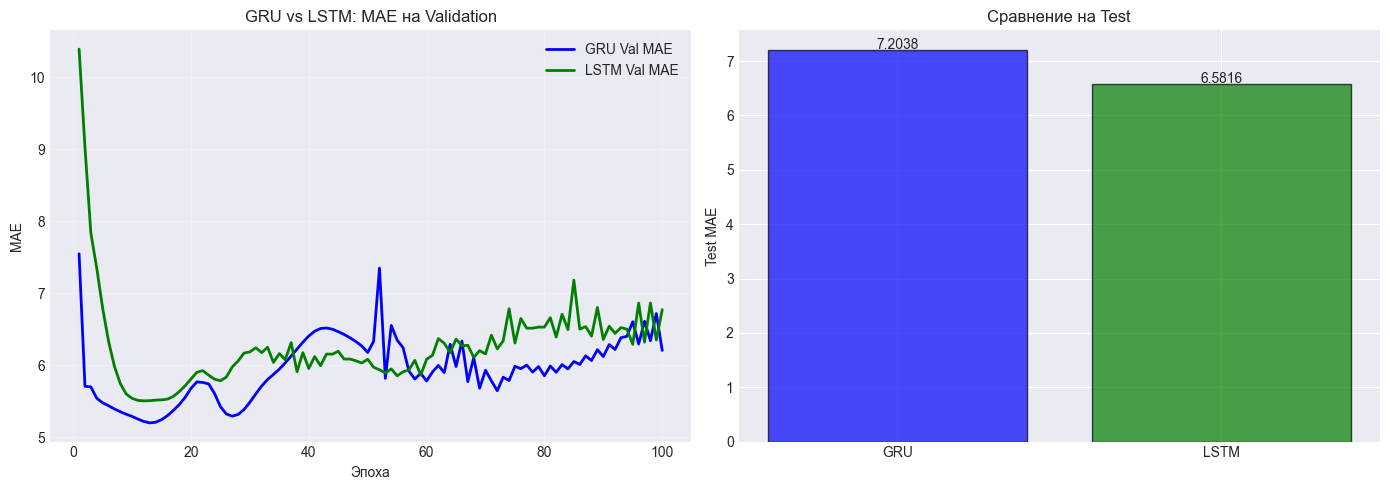

Сохранено: artifacts/figures/gru_vs_lstm_compare.png


In [36]:
# Финальная визуализация — GRU vs LSTM сравнение
# === figures/gru_vs_lstm_compare.png ===
plt.figure(figsize=(14, 5))

# Сравнение по эпохам
epochs_range = range(1, len(history['val_mae']) + 1)

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['val_mae'], label='GRU Val MAE', linewidth=2, color='blue')
plt.plot(epochs_range, lstm_history['val_mae'], label='LSTM Val MAE', linewidth=2, color='green')
plt.xlabel('Эпоха')
plt.ylabel('MAE')
plt.title('GRU vs LSTM: MAE на Validation')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
models = ['GRU', 'LSTM']
test_maes = [test_mae, test_mae_lstm]
colors = ['blue', 'green']

plt.bar(models, test_maes, color=colors, edgecolor='black', alpha=0.7)
plt.ylabel('Test MAE')
plt.title('Сравнение на Test')
for i, v in enumerate(test_maes):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center')

plt.tight_layout()
plt.savefig('artifacts/figures/gru_vs_lstm_compare.png', dpi=300)
plt.show()

print("Сохранено: artifacts/figures/gru_vs_lstm_compare.png")

In [37]:
# === Финальная проверка всех артефактов ===
print("=== ПРОВЕРКА ВСЕХ АРТЕФАКТОВ ===\n")

required_files = [
    'artifacts/runs.csv',
    'artifacts/best_gru.pt',
    'artifacts/best_gru_config.json',
    'artifacts/best_lstm.pt',
    'artifacts/figures/series_split.png',
    'artifacts/figures/baselines_compare.png',
    'artifacts/figures/gru_learning_curves.png',
    'artifacts/figures/best_forecast_test.png',
    'artifacts/figures/residuals_best.png',
    'artifacts/figures/error_by_time.png',
    'artifacts/figures/feature_examples.png',
    'artifacts/figures/error_by_segment.png',
    'artifacts/figures/tsc_examples.png',
    'artifacts/figures/gru_vs_lstm_compare.png'
]

all_present = True
for filepath in required_files:
    if os.path.exists(filepath):
        size = os.path.getsize(filepath)
        print(f"[OK] {filepath} ({size:,} байт)")
    else:
        print(f"[MISSING] {filepath}")
        all_present = False

print("\n" + "="*50)
if all_present:
    print("ВСЕ АРТЕФАКТЫ СОЗДАНЫ УСПЕШНО")
else:
    print("ВНИМАНИЕ: Некоторые файлы отсутствуют")
print("="*50)

# Сводка по экспериментам
print("\n=== СВОДКА ПО ЭКСПЕРИМЕНТАМ ===")
print(f"Обязательные: B1, B2, B3, R1")
print(f"Опциональные: R2 (LSTM), R3 (window tuning), B4 (Random Forest), TSC_BONUS")
print(f"Всего экспериментов: {len(runs_df)}")
print(f"\nЛучшая модель по validation MAE: {runs_df.loc[runs_df['best_val_mae'].idxmin(), 'experiment_id']}")

=== ПРОВЕРКА ВСЕХ АРТЕФАКТОВ ===

[OK] artifacts/runs.csv (2,961 байт)
[OK] artifacts/best_gru.pt (160,981 байт)
[OK] artifacts/best_gru_config.json (514 байт)
[OK] artifacts/best_lstm.pt (213,221 байт)
[MISSING] artifacts/figures/series_split.png
[OK] artifacts/figures/baselines_compare.png (65,761 байт)
[OK] artifacts/figures/gru_learning_curves.png (374,569 байт)
[OK] artifacts/figures/best_forecast_test.png (626,340 байт)
[OK] artifacts/figures/residuals_best.png (527,022 байт)
[OK] artifacts/figures/error_by_time.png (100,194 байт)
[OK] artifacts/figures/feature_examples.png (697,051 байт)
[OK] artifacts/figures/error_by_segment.png (92,084 байт)
[OK] artifacts/figures/tsc_examples.png (399,452 байт)
[OK] artifacts/figures/gru_vs_lstm_compare.png (222,691 байт)

ВНИМАНИЕ: Некоторые файлы отсутствуют

=== СВОДКА ПО ЭКСПЕРИМЕНТАМ ===
Обязательные: B1, B2, B3, R1
Опциональные: R2 (LSTM), R3 (window tuning), B4 (Random Forest), TSC_BONUS
Всего экспериментов: 8

Лучшая модель по valida